# barrierQP

A tiny JAX solver for dense, strictly convex quadratic programs

$$\min_x\ \tfrac12 x^\top P x + q^\top x \quad\text{s.t.}\quad A x = b,\ G x \le h,\qquad P\succ0.$$

It is a dense Mehrotra predictor-corrector interior-point method: each iteration
factors **one** KKT matrix and reuses that single factorization for both the
affine predictor and the centered corrector direction. This notebook solves a
small 2-D problem, looks at the solution, and re-solves with a different linear
term.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update("jax_enable_x64", True)   # dense KKT solves want float64
import barrierqp

## A pentagon

The feasible set is the square $[-1,1]^2$ cut by the diagonal
$0.625\,(x_1+x_2)\le 1$. The quadratic objective is chosen so the optimum sits on
that diagonal cut.

In [2]:
G = np.array([[1., 0.], [0., 1.], [0.625, 0.625], [-1., 0.], [0., -1.]])
h = np.ones(5)
P = np.array([[2.0, 0.5], [0.5, 1.5]])
q = np.array([-2.7, -2.175])
A, b = np.zeros((0, 2)), np.zeros(0)          # no equality rows here

result = barrierqp.Solver(P, q, A, b, G, h).solve()
x_star = np.asarray(result.x)
kkt = float(np.max(np.abs(P @ x_star + q + G.T @ np.asarray(result.z))))
print("status        ", result.status)
print("iterations    ", result.iterations)
print("factorizations", result.factorizations, "  (one per iteration)")
print("Newton solves ", result.newton_solves, "  (affine + corrector, shared factor)")
print("KKT residual  ", f"{kkt:.2e}")
print("optimum       ", np.round(x_star, 6))

status         solved
iterations     6
factorizations 6   (one per iteration)
Newton solves  12   (affine + corrector, shared factor)
KKT residual   8.47e-10
optimum        [0.85 0.75]


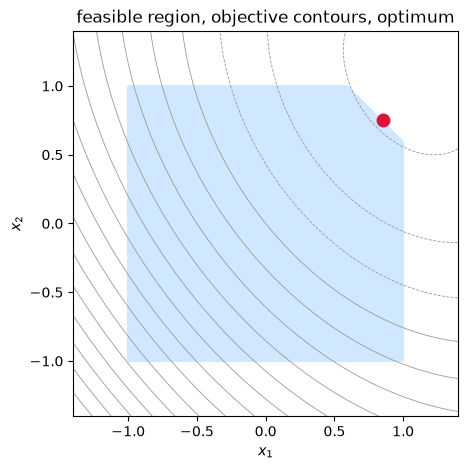

In [3]:
def plot_qp(P, q, x_star, ax, title):
    g = np.linspace(-1.4, 1.4, 300)
    X, Y = np.meshgrid(g, g)
    pts = np.stack([X.ravel(), Y.ravel()], axis=1)
    obj = (0.5 * np.einsum("ij,jk,ik->i", pts, P, pts) + pts @ q).reshape(X.shape)
    feas = np.all(pts @ G.T <= h + 1e-9, axis=1).reshape(X.shape)
    ax.contourf(X, Y, feas, levels=[0.5, 1.5], colors=["#cfe8ff"])
    ax.contour(X, Y, obj, levels=18, colors="0.6", linewidths=0.6)
    ax.plot(*x_star, "o", color="crimson", ms=9)
    ax.set_aspect("equal"); ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_title(title)

fig, ax = plt.subplots(figsize=(5, 5))
plot_qp(P, q, x_star, ax, "feasible region, objective contours, optimum")
plt.show()

## Change the objective, solve again

Only the linear term $q$ changes; the same solver call returns a different
optimum on the boundary.

new optimum    [ 0.75 -1.  ]  in 6 iterations


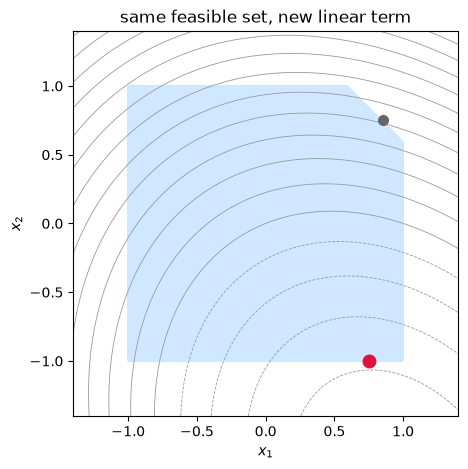

In [4]:
q2 = np.array([-1.0, 2.5])
r2 = barrierqp.Solver(P, q2, A, b, G, h).solve()
x2 = np.asarray(r2.x)
print("new optimum   ", np.round(x2, 6), " in", r2.iterations, "iterations")

fig, ax = plt.subplots(figsize=(5, 5))
plot_qp(P, q2, x2, ax, "same feasible set, new linear term")
ax.plot(*x_star, "o", color="0.4", ms=7)            # the earlier optimum, for contrast
plt.show()

Each iteration builds and factors one reduced KKT matrix and asks it two
questions -- the affine predictor and the centered corrector -- so an
$N$-iteration solve does exactly $N$ factorizations and $2N$ Newton solves. That
single reuse is the whole idea.